# 🎮 SASRec Steam 游戏推荐系统 — 全合一 Notebook

所有模块（`sampler` / `modules` / `model` / `util` / `main`）均已内联，无需任何外部 `.py` 文件。

**运行前唯一要求：** 项目目录下存在 `data/Steam.txt`（如没有，先运行 **Cell 1** 的数据预处理）

---
按顺序执行每个 Cell 即可完成完整训练。

## ⚙️ Cell 1 — 数据预处理（已有 data/Steam.txt 可跳过）

In [14]:
import gzip, ast

with gzip.open(r'D:\Desktop\521group3.25\steam\reviews_steam.json.gz', 'rb') as g:
    for i, line in enumerate(g):
        data = ast.literal_eval(line.decode('utf-8'))
        print(data)
        break  # 只看第一条

{'publisher': 'Kotoshiro', 'genres': ['Action', 'Casual', 'Indie', 'Simulation', 'Strategy'], 'app_name': 'Lost Summoner Kitty', 'title': 'Lost Summoner Kitty', 'url': 'http://store.steampowered.com/app/761140/Lost_Summoner_Kitty/', 'release_date': '2018-01-04', 'tags': ['Strategy', 'Action', 'Indie', 'Casual', 'Simulation'], 'discount_price': 4.49, 'reviews_url': 'http://steamcommunity.com/app/761140/reviews/?browsefilter=mostrecent&p=1', 'specs': ['Single-player'], 'price': 4.99, 'early_access': False, 'id': '761140', 'developer': 'Kotoshiro'}


In [16]:
with open(r'D:\Desktop\521group3.25\steam\steam_games.json', 'r', encoding='utf-8') as f:
    content = f.read(500)  # 只读前500个字符
print(repr(content))

"{u'publisher': u'Kotoshiro', u'genres': [u'Action', u'Casual', u'Indie', u'Simulation', u'Strategy'], u'app_name': u'Lost Summoner Kitty', u'title': u'Lost Summoner Kitty', u'url': u'http://store.steampowered.com/app/761140/Lost_Summoner_Kitty/', u'release_date': u'2018-01-04', u'tags': [u'Strategy', u'Action', u'Indie', u'Casual', u'Simulation'], u'discount_price': 4.49, u'reviews_url': u'http://steamcommunity.com/app/761140/reviews/?browsefilter=mostrecent&p=1', u'specs': [u'Single-player'], u"


In [13]:

# ================== DataProcessing.py 内容 ==================
# 如果已有 data/Steam.txt，直接跳到 Cell 2
# 运行前确保 reviews_steam.json.gz 在当前目录

import gzip
import ast
from collections import defaultdict
from datetime import datetime
import os

input_file  = 'reviews_steam.json.gz'
output_dir  = 'data'
output_file = os.path.join(output_dir, 'Steam.txt')

os.makedirs(output_dir, exist_ok=True)

MAX_USERS = 50000
K_CORE    = 10

def parse(path):
    with gzip.open(path, 'rb') as g:
        for l in g:
            yield ast.literal_eval(l.decode('utf-8'))

countU = defaultdict(int)
countP = defaultdict(int)
line   = 0

print(f'第一次扫描：统计交互次数 (K-core={K_CORE})...')
for l in parse(input_file):
    line += 1
    countU[l['username']]   += 1
    countP[l['product_id']] += 1
    if line % 200000 == 0:
        print(f'  已扫描 {line} 行...')

usermap, usernum = {}, 0
itemmap, itemnum = {}, 0
User = {}

print('第二次扫描：过滤 & 构建用户序列...')
for l in parse(input_file):
    user = l['username']
    item = l['product_id']
    if countU[user] < K_CORE or countP[item] < K_CORE:
        continue
    if user not in usermap:
        if usernum >= MAX_USERS:
            continue
        usernum += 1
        usermap[user] = usernum
        User[usernum]  = []
    userid = usermap[user]
    date_str = l['date']
    try:
        ts = datetime.strptime(date_str, '%Y-%m-%d').timestamp()
    except:
        try:
            ts = datetime.strptime(date_str, '%d %B, %Y').timestamp()
        except:
            ts = 0
    if item not in itemmap:
        itemnum += 1
        itemmap[item] = itemnum
    User[userid].append([ts, itemmap[item]])

print(f'过滤完成：用户 {usernum}, 物品 {itemnum}')

with open(output_file, 'w') as f:
    for uid in User:
        User[uid].sort(key=lambda x: x[0])
        for interaction in User[uid]:
            f.write(f'{uid} {interaction[1]}\n')

print(f'✅ 数据已写入 {output_file}')


第一次扫描：统计交互次数 (K-core=10)...


KeyError: 'username'

In [19]:
import ast

# 用 ast.literal_eval 读取 Python2 格式的文件
game_info = {}
with open(r'D:\Desktop\521group3.25\steam\steam_games.json', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            game = ast.literal_eval(line)
            if 'id' in game and 'title' in game:
                game_info[str(game['id'])] = game
        except:
            continue

print(f'✅ 游戏信息加载完成，共 {len(game_info)} 款游戏')
sample_keys = list(game_info.keys())[:3]

for k in sample_keys:
    print(f'  app_id: {k} → {game_info[k]["title"]}')

✅ 游戏信息加载完成，共 30083 款游戏
  app_id: 761140 → Lost Summoner Kitty
  app_id: 643980 → Ironbound
  app_id: 670290 → Real Pool 3D - Poolians


## ⚙️ Cell 2 — 环境初始化 & TensorFlow 配置

In [29]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
print("ok")

ok


In [30]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import sys
import time
import copy
import random
import numpy as np
from collections import defaultdict
from threading import Thread
from queue import Queue

import tensorflow.compat.v1 as tf1
tf1.disable_v2_behavior()
import tensorflow as tf

from tensorflow.python.framework import dtypes
if not hasattr(dtypes, 'float32_ref'):
    dtypes.float32_ref = tf.float32

from tqdm.notebook import tqdm

print('✅ TensorFlow:', tf.__version__)
print('✅ Python     :', sys.version.split()[0])

✅ TensorFlow: 2.20.0
✅ Python     : 3.13.5


## 📦 Cell 3 — sampler 模块（多线程负采样）

In [31]:
# ================== sampler.py 内容（已修复为 threading）==================
# 原版使用 multiprocessing，在 Windows + Jupyter 下因 spawn 机制崩溃。
# 改用 threading.Thread，完全规避该问题，功能完全等价。

def random_neq(l, r, s):
    """在 [l, r) 中随机采样一个不在集合 s 中的整数"""
    t = np.random.randint(l, r)
    while t in s:
        t = np.random.randint(l, r)
    return t


def _sample_function(user_train, usernum, itemnum, batch_size, maxlen, result_queue, SEED):
    """后台线程持续生成训练批次并放入队列"""
    def sample():
        # 随机选一个至少有 2 条交互的用户
        user = np.random.randint(1, usernum + 1)
        while len(user_train[user]) <= 1:
            user = np.random.randint(1, usernum + 1)

        seq = np.zeros([maxlen], dtype=np.int32)   # 输入序列（历史交互）
        pos = np.zeros([maxlen], dtype=np.int32)   # 正样本（下一个物品）
        neg = np.zeros([maxlen], dtype=np.int32)   # 负样本（随机未交互物品）
        nxt = user_train[user][-1]
        idx = maxlen - 1

        ts = set(user_train[user])  # 该用户所有交互物品（用于负采样排除）
        for i in reversed(user_train[user][:-1]):
            seq[idx] = i
            pos[idx] = nxt
            if nxt != 0:
                neg[idx] = random_neq(1, itemnum + 1, ts)
            nxt = i
            idx -= 1
            if idx == -1:
                break
        return (user, seq, pos, neg)

    np.random.seed(SEED)
    while True:
        one_batch = [sample() for _ in range(batch_size)]
        # 转成 list 确保数据在放入队列前已实体化（zip 是惰性的）
        result_queue.put(list(zip(*one_batch)))


class WarpSampler:
    def __init__(self, User, usernum, itemnum, batch_size=64, maxlen=10, n_workers=1):
        self.result_queue = Queue(maxsize=n_workers * 10)
        self.workers = []
        for _ in range(n_workers):
            t = Thread(
                target=_sample_function,
                args=(User, usernum, itemnum, batch_size, maxlen,
                      self.result_queue, np.random.randint(int(2e9)))
            )
            t.daemon = True   # 主线程退出时自动回收
            t.start()
            self.workers.append(t)

    def next_batch(self):
        return self.result_queue.get()

    def close(self):
        pass   # daemon 线程随主线程自动退出，无需手动 terminate

print('✅ WarpSampler 定义完成')

✅ WarpSampler 定义完成


## 📦 Cell 4 — modules 模块（Transformer 基础组件）

In [32]:
def positional_encoding(dim, sentence_length, dtype=tf1.float32):
    encoded_vec = np.array([
        pos / np.power(10000, 2.0 * (i // 2) / dim)
        for pos in range(sentence_length) for i in range(dim)
    ])
    encoded_vec[::2]  = np.sin(encoded_vec[::2])
    encoded_vec[1::2] = np.cos(encoded_vec[1::2])
    return tf1.convert_to_tensor(encoded_vec.reshape([sentence_length, dim]), dtype=dtype)


def normalize(inputs, epsilon=1e-8, scope='ln', reuse=None):
    with tf1.variable_scope(scope, reuse=reuse):
        params_shape = inputs.get_shape()[-1:]
        mean, variance = tf1.nn.moments(inputs, [-1], keepdims=True)
        beta  = tf1.Variable(tf1.zeros(params_shape))
        gamma = tf1.Variable(tf1.ones(params_shape))
        normalized = (inputs - mean) / ((variance + epsilon) ** 0.5)
        return gamma * normalized + beta


def embedding(inputs, vocab_size, num_units, zero_pad=True, scale=True,
              l2_reg=0.0, scope='embedding', with_t=False, reuse=None):
    with tf1.variable_scope(scope, reuse=reuse):
        lookup_table = tf1.get_variable(
            'lookup_table', dtype=tf1.float32,
            shape=[vocab_size, num_units],
            regularizer=tf1.keras.regularizers.l2(l2_reg) if l2_reg > 0 else None
        )
        if zero_pad:
            lookup_table = tf1.concat(
                [tf1.zeros(shape=[1, num_units]), lookup_table[1:, :]], axis=0
            )
        outputs = tf1.nn.embedding_lookup(lookup_table, inputs)
        if scale:
            outputs = outputs * (num_units ** 0.5)
    return (outputs, lookup_table) if with_t else outputs


def dropout(inputs, rate, is_training):
    """统一的 dropout，兼容 Keras 3 + TF2.21"""
    return tf1.cond(
        is_training,
        lambda: tf1.nn.dropout(inputs, rate=rate),
        lambda: inputs
    )


def multihead_attention(queries, keys, num_units=None, num_heads=8,
                        dropout_rate=0, is_training=True, causality=False,
                        scope='multihead_attention', reuse=None, with_qk=False):
    with tf1.variable_scope(scope, reuse=reuse):
        if num_units is None:
            num_units = queries.get_shape().as_list()[-1]

        Q = tf1.layers.dense(queries, num_units, activation=None)
        K = tf1.layers.dense(keys,    num_units, activation=None)
        V = tf1.layers.dense(keys,    num_units, activation=None)

        Q_ = tf1.concat(tf1.split(Q, num_heads, axis=2), axis=0)
        K_ = tf1.concat(tf1.split(K, num_heads, axis=2), axis=0)
        V_ = tf1.concat(tf1.split(V, num_heads, axis=2), axis=0)

        outputs = tf1.matmul(Q_, tf1.transpose(K_, [0, 2, 1]))
        outputs = outputs / (K_.get_shape().as_list()[-1] ** 0.5)

        key_masks = tf1.sign(tf1.reduce_sum(tf1.abs(keys), axis=-1))
        key_masks = tf1.tile(key_masks, [num_heads, 1])
        key_masks = tf1.tile(tf1.expand_dims(key_masks, 1), [1, tf1.shape(queries)[1], 1])
        paddings  = tf1.ones_like(outputs) * (-2 ** 32 + 1)
        outputs   = tf1.where(tf1.equal(key_masks, 0), paddings, outputs)

        if causality:
            diag_vals = tf1.ones_like(outputs[0, :, :])
            tril      = tf1.linalg.band_part(diag_vals, -1, 0)
            masks     = tf1.tile(tf1.expand_dims(tril, 0), [tf1.shape(outputs)[0], 1, 1])
            paddings  = tf1.ones_like(masks) * (-2 ** 32 + 1)
            outputs   = tf1.where(tf1.equal(masks, 0), paddings, outputs)

        outputs = tf1.nn.softmax(outputs)

        query_masks = tf1.sign(tf1.reduce_sum(tf1.abs(queries), axis=-1))
        query_masks = tf1.tile(query_masks, [num_heads, 1])
        query_masks = tf1.tile(tf1.expand_dims(query_masks, -1), [1, 1, tf1.shape(keys)[1]])
        outputs    *= query_masks

        outputs = dropout(outputs, rate=dropout_rate, is_training=is_training)
        outputs = tf1.matmul(outputs, V_)
        outputs = tf1.concat(tf1.split(outputs, num_heads, axis=0), axis=2)
        outputs += queries

    return (Q, K) if with_qk else outputs


def feedforward(inputs, num_units=[2048, 512], scope='feedforward',
                dropout_rate=0.2, is_training=True, reuse=None):
    with tf1.variable_scope(scope, reuse=reuse):
        out = tf1.layers.conv1d(inputs,  num_units[0], kernel_size=1, activation=tf1.nn.relu)
        out = dropout(out, rate=dropout_rate, is_training=is_training)
        out = tf1.layers.conv1d(out, num_units[1], kernel_size=1, activation=None)
        out = dropout(out, rate=dropout_rate, is_training=is_training)
        out += inputs
    return out

print('✅ Transformer 模块定义完成')

✅ Transformer 模块定义完成


## 📦 Cell 5 — model 模块（SASRec 计算图）

In [33]:
# ================== model.py 内容 ==================

class Model:
    """
    SASRec：Self-Attentive Sequential Recommendation
    输入用户历史交互序列，通过多层因果 Transformer 预测下一个感兴趣的物品。
    """
    def __init__(self, usernum, itemnum, args, reuse=None):
        # ---------- 输入占位符 ----------
        self.is_training = tf1.placeholder(tf1.bool,  shape=())
        self.u           = tf1.placeholder(tf1.int32, shape=(None,))
        self.input_seq   = tf1.placeholder(tf1.int32, shape=(None, args.maxlen))
        self.pos         = tf1.placeholder(tf1.int32, shape=(None, args.maxlen))
        self.neg         = tf1.placeholder(tf1.int32, shape=(None, args.maxlen))
        pos = self.pos
        neg = self.neg

        # padding mask：input_seq 中非 0 位置为 1
        mask = tf1.expand_dims(
            tf1.cast(tf1.not_equal(self.input_seq, 0), dtype=tf1.float32), -1
        )

        with tf1.variable_scope('SASRec', reuse=reuse):
            # 物品嵌入（vocab_size = itemnum+1，第0行保留为 padding）
            self.seq, item_emb_table = embedding(
                self.input_seq, vocab_size=itemnum + 1,
                num_units=args.hidden_units, zero_pad=True, scale=True,
                l2_reg=args.l2_emb, scope='input_embeddings', with_t=True, reuse=reuse
            )

            # 可学习位置嵌入
            t, _ = embedding(
                tf1.tile(
                    tf1.expand_dims(tf1.range(tf1.shape(self.input_seq)[1]), 0),
                    [tf1.shape(self.input_seq)[0], 1]
                ),
                vocab_size=args.maxlen, num_units=args.hidden_units,
                zero_pad=False, scale=False,
                l2_reg=args.l2_emb, scope='position_embeddings', with_t=True, reuse=reuse
            )
            self.seq += t

            # Dropout + padding mask
            self.seq = tf1.layers.dropout(
                self.seq, rate=args.dropout_rate,
                training=tf1.convert_to_tensor(self.is_training)
            )
            self.seq *= mask

            # 多层 Transformer Block
            for i in range(args.num_blocks):
                with tf1.variable_scope(f'num_blocks_{i}'):
                    # 因果自注意力
                    self.seq = multihead_attention(
                        queries=normalize(self.seq), keys=self.seq,
                        num_units=args.hidden_units, num_heads=args.num_heads,
                        dropout_rate=args.dropout_rate, is_training=self.is_training,
                        causality=True, scope='self_attention'
                    )
                    # 前馈网络
                    self.seq = feedforward(
                        normalize(self.seq),
                        num_units=[args.hidden_units, args.hidden_units],
                        dropout_rate=args.dropout_rate, is_training=self.is_training
                    )
                    self.seq *= mask

            self.seq = normalize(self.seq)

        # ---------- 训练：正负样本得分 & 损失 ----------
        pos_emb = tf1.nn.embedding_lookup(item_emb_table, pos)
        neg_emb = tf1.nn.embedding_lookup(item_emb_table, neg)

        seq_emb = tf1.reshape(self.seq,    [tf1.shape(self.input_seq)[0] * args.maxlen, args.hidden_units])
        pos_emb = tf1.reshape(pos_emb,     [tf1.shape(self.input_seq)[0] * args.maxlen, args.hidden_units])
        neg_emb = tf1.reshape(neg_emb,     [tf1.shape(self.input_seq)[0] * args.maxlen, args.hidden_units])

        # ---------- 测试：对候选物品打分 ----------
        self.test_item  = tf1.placeholder(tf1.int32, shape=(None,))
        test_item_emb   = tf1.nn.embedding_lookup(item_emb_table, self.test_item)
        self.test_logits = tf1.matmul(seq_emb, tf1.transpose(test_item_emb))
        self.test_logits = tf1.reshape(
            self.test_logits,
            [tf1.shape(self.input_seq)[0], args.maxlen, tf1.shape(self.test_item)[0]]
        )
        self.test_logits = self.test_logits[:, -1, :]   # 取序列最后一步的预测

        # 点积得分
        self.pos_logits = tf1.reduce_sum(pos_emb * seq_emb, -1)
        self.neg_logits = tf1.reduce_sum(neg_emb * seq_emb, -1)

        # 有效位置 mask（排除 padding 位置的损失）
        istarget = tf1.reshape(
            tf1.cast(tf1.not_equal(pos, 0), dtype=tf1.float32),
            [tf1.shape(self.input_seq)[0] * args.maxlen]
        )

        # 二元交叉熵损失
        self.loss = tf1.reduce_sum(
            - tf1.log(tf1.sigmoid(self.pos_logits) + 1e-24) * istarget
            - tf1.log(1 - tf1.sigmoid(self.neg_logits) + 1e-24) * istarget
        ) / tf1.reduce_sum(istarget)

        # L2 正则损失
        self.loss += sum(tf1.get_collection(tf1.GraphKeys.REGULARIZATION_LOSSES))

        # AUC 近似
        self.auc = tf1.reduce_sum(
            ((tf1.sign(self.pos_logits - self.neg_logits) + 1) / 2) * istarget
        ) / tf1.reduce_sum(istarget)

        if reuse is None:
            self.global_step = tf1.Variable(0, name='global_step', trainable=False)
            self.optimizer   = tf1.train.AdamOptimizer(learning_rate=args.lr, beta2=0.98)
            self.train_op    = self.optimizer.minimize(self.loss, global_step=self.global_step)

    def predict(self, sess, u, seq, item_idx):
        """推理：返回候选物品的得分向量"""
        return sess.run(
            self.test_logits,
            {self.u: u, self.input_seq: seq,
             self.test_item: item_idx, self.is_training: False}
        )

print('✅ Model 类定义完成')

✅ Model 类定义完成


## 📦 Cell 6 — util 模块（数据加载 & 评估指标）

In [34]:
# ================== util.py 内容 ==================

def data_partition(fname):
    """
    读取 data/{fname}.txt，按 Leave-one-out 划分训练/验证/测试集。
    倒数第2条交互 → 验证集，最后1条 → 测试集，其余 → 训练集。
    """
    usernum, itemnum = 0, 0
    User = defaultdict(list)
    user_train, user_valid, user_test = {}, {}, {}

    with open(f'data/{fname}.txt', 'r') as f:
        for line in f:
            u, i = line.rstrip().split(' ')
            u, i = int(u), int(i)
            usernum = max(u, usernum)
            itemnum = max(i, itemnum)
            User[u].append(i)

    for user in User:
        nfeedback = len(User[user])
        if nfeedback < 3:
            user_train[user] = User[user]
            user_valid[user] = []
            user_test[user]  = []
        else:
            user_train[user] = User[user][:-2]
            user_valid[user] = [User[user][-2]]
            user_test[user]  = [User[user][-1]]

    return [user_train, user_valid, user_test, usernum, itemnum]


def evaluate(model, dataset, args, sess):
    """
    测试集评估：NDCG@10 和 HR@10。
    每个用户从全量物品随机采 100 个负样本 + 1 个正样本共 101 个候选排序。
    """
    [train, valid, test, usernum, itemnum] = copy.deepcopy(dataset)
    NDCG, HT, valid_user = 0.0, 0.0, 0.0

    users = (random.sample(range(1, usernum + 1), 10000)
             if usernum > 10000 else range(1, usernum + 1))

    for u in users:
        if len(train[u]) < 1 or len(test[u]) < 1:
            continue
        seq     = np.zeros([args.maxlen], dtype=np.int32)
        idx     = args.maxlen - 1
        seq[idx] = valid[u][0]   # 把验证集物品加入序列末尾
        idx -= 1
        for i in reversed(train[u]):
            seq[idx] = i
            idx -= 1
            if idx == -1:
                break

        rated    = set(train[u]) | {0}
        item_idx = [test[u][0]]
        while len(item_idx) < 101:
            t = np.random.randint(1, itemnum + 1)
            if t not in rated:
                item_idx.append(t)

        predictions = -model.predict(sess, [u], [seq], item_idx)[0]
        rank        = predictions.argsort().argsort()[0]
        valid_user += 1
        if rank < 10:
            NDCG += 1 / np.log2(rank + 2)
            HT   += 1
        if valid_user % 100 == 0:
            print('.', end='', flush=True)

    return NDCG / valid_user, HT / valid_user


def evaluate_valid(model, dataset, args, sess):
    """
    验证集评估：同 evaluate，但用验证集物品作为正样本。
    """
    [train, valid, test, usernum, itemnum] = copy.deepcopy(dataset)
    NDCG, HT, valid_user = 0.0, 0.0, 0.0

    users = (random.sample(range(1, usernum + 1), 10000)
             if usernum > 10000 else range(1, usernum + 1))

    for u in users:
        if len(train[u]) < 1 or len(valid[u]) < 1:
            continue
        seq = np.zeros([args.maxlen], dtype=np.int32)
        idx = args.maxlen - 1
        for i in reversed(train[u]):
            seq[idx] = i
            idx -= 1
            if idx == -1:
                break

        rated    = set(train[u]) | {0}
        item_idx = [valid[u][0]]
        while len(item_idx) < 101:
            t = np.random.randint(1, itemnum + 1)
            if t not in rated:
                item_idx.append(t)

        predictions = -model.predict(sess, [u], [seq], item_idx)[0]
        rank        = predictions.argsort().argsort()[0]
        valid_user += 1
        if rank < 10:
            NDCG += 1 / np.log2(rank + 2)
            HT   += 1
        if valid_user % 100 == 0:
            print('.', end='', flush=True)

    return NDCG / valid_user, HT / valid_user

print('✅ 数据 & 评估函数定义完成')

✅ 数据 & 评估函数定义完成


## ⚙️ Cell 7 — 超参数配置

对应命令行：`python main.py --dataset=Steam --train_dir=default --maxlen=50 --dropout_rate=0.2`

In [35]:
class Args:
    dataset      = 'Steam'
    train_dir    = 'default'
    batch_size   = 128
    lr           = 0.001
    maxlen       = 50       # 输入序列最大长度
    hidden_units = 50       # Transformer 隐藏维度
    num_blocks   = 2        # Transformer Block 层数
    num_epochs   = 20       # 训练轮次
    num_heads    = 1        # 多头注意力头数
    dropout_rate = 0.2      # Dropout 比例（命令行指定）
    l2_emb       = 0.0      # Embedding L2 正则系数

args    = Args()
log_dir = f'{args.dataset}_{args.train_dir}'
os.makedirs(log_dir, exist_ok=True)

print('✅ 超参数配置完成')
print(f'   数据集: {args.dataset}  |  日志目录: {log_dir}')
print(f'   maxlen={args.maxlen}, hidden={args.hidden_units}, blocks={args.num_blocks}')
print(f'   lr={args.lr}, dropout={args.dropout_rate}, epochs={args.num_epochs}')

✅ 超参数配置完成
   数据集: Steam  |  日志目录: Steam_default
   maxlen=50, hidden=50, blocks=2
   lr=0.001, dropout=0.2, epochs=20


## ⚙️ Cell 8 — 加载数据集

In [36]:
dataset = data_partition(args.dataset)
[user_train, user_valid, user_test, usernum, itemnum] = dataset

num_batch = int(len(user_train) / args.batch_size)
avg_len   = sum(len(user_train[u]) for u in user_train) / len(user_train)

print(f'✅ 数据加载完成')
print(f'   用户数:       {usernum}')
print(f'   物品数:       {itemnum}')
print(f'   平均序列长度: {avg_len:.2f}')
print(f'   每轮批次数:   {num_batch}')

✅ 数据加载完成
   用户数:       50000
   物品数:       11292
   平均序列长度: 32.01
   每轮批次数:   390


In [21]:
import numpy as np

inv_itemmap = np.load("inv_itemmap.npy", allow_pickle=True).item()

itemname = {}

for iid, rawid in inv_itemmap.items():
    itemname[iid] = game_info.get(str(rawid),"Unknown")

## ⚙️ Cell 9 — 构建计算图 & 初始化

In [37]:
# 重置计算图（重复运行此 Cell 时防止变量重名报错）
tf1.reset_default_graph()

config = tf1.ConfigProto()
config.gpu_options.allow_growth = True
config.allow_soft_placement     = True
sess = tf1.Session(config=config)

# 启动后台采样线程（threading 版，Jupyter 安全）
sampler = WarpSampler(
    user_train, usernum, itemnum,
    batch_size=args.batch_size,
    maxlen=args.maxlen,
    n_workers=3
)

model = Model(usernum, itemnum, args)
saver = tf1.train.Saver(max_to_keep=3)
sess.run(tf1.global_variables_initializer())

print('✅ TF Session 已创建')
print('✅ 采样线程已启动')
print('✅ 模型变量已初始化，可以开始训练')

C:\Users\LIU Hang\AppData\Local\Temp\ipykernel_10516\2875884271.py:44: UserWarning: `tf.layers.dropout` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dropout` instead.
  self.seq = tf1.layers.dropout(
C:\Users\LIU Hang\AppData\Local\Temp\ipykernel_10516\735429018.py:55: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  Q = tf1.layers.dense(queries, num_units, activation=None)
C:\Users\LIU Hang\AppData\Local\Temp\ipykernel_10516\735429018.py:56: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  K = tf1.layers.dense(keys,    num_units, activation=None)
C:\Users\LIU Hang\AppData\Local\Temp\ipykernel_10516\735429018.py:57: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  V = tf1.layers.dense(keys,    num_units,

✅ TF Session 已创建
✅ 采样线程已启动
✅ 模型变量已初始化，可以开始训练


## 🚀 Cell 10 — 训练主循环

In [52]:

T        = 0.0
t0       = time.time()
log_path = os.path.join(log_dir, 'training_log.txt')

print('🚀 开始训练...')
print(f'   共 {args.num_epochs} 轮，每轮 {num_batch} 个 batch，每 5 轮评估一次\n')

try:
    for epoch in range(start_epoch, args.num_epochs + 1):

        pbar = tqdm(range(num_batch),
                    desc=f'Epoch {epoch:02d}/{args.num_epochs}',
                    leave=True)

        for step in pbar:
            u, seq, pos, neg = sampler.next_batch()
            auc, loss, _ = sess.run(
                [model.auc, model.loss, model.train_op],
                feed_dict={
                    model.u:           u,
                    model.input_seq:   seq,
                    model.pos:         pos,
                    model.neg:         neg,
                    model.is_training: True
                }
            )
            pbar.set_postfix(loss=f'{loss:.4f}', auc=f'{auc:.4f}')

        # 每 5 轮或最后一轮：评估 + 保存
        if epoch % 5 == 0 or epoch == args.num_epochs:
            t1  = time.time() - t0
            T  += t1
            print(f'\n📊 评估中 (Epoch {epoch})...')

            t_valid = evaluate_valid(model, dataset, args, sess)
            t_test  = evaluate(model, dataset, args, sess)

            print(f'\n⏱  累计时间: {T:.1f}s')
            print(f'✔  Valid → NDCG@10: {t_valid[0]:.4f}  HR@10: {t_valid[1]:.4f}')
            print(f'✔  Test  → NDCG@10: {t_test[0]:.4f}  HR@10: {t_test[1]:.4f}')

            # 写训练日志
            with open(log_path, 'a') as f:
                f.write(
                    f'Epoch {epoch}: '
                    f'Valid_NDCG {t_valid[0]:.4f}, Valid_HR {t_valid[1]:.4f}, '
                    f'Test_NDCG {t_test[0]:.4f}, Test_HR {t_test[1]:.4f}\n'
                )

            # 保存模型 checkpoint
            ckpt_path = os.path.join(log_dir, 'sasrec_model.ckpt')
            saver.save(sess, ckpt_path, global_step=epoch)
            print(f'💾 模型已保存: {ckpt_path}-{epoch}\n')

            t0 = time.time()  # 重置计时

except KeyboardInterrupt:
    print('\n⏹ 手动中断训练')
except Exception as e:
    import traceback
    print(f'\n❌ 训练出错: {e}')
    traceback.print_exc()
finally:
    sampler.close()
    print('\n✅ 训练结束')

🚀 开始训练...
   共 20 轮，每轮 390 个 batch，每 5 轮评估一次


✅ 训练结束


## 📈 Cell 11 — 可视化训练曲线

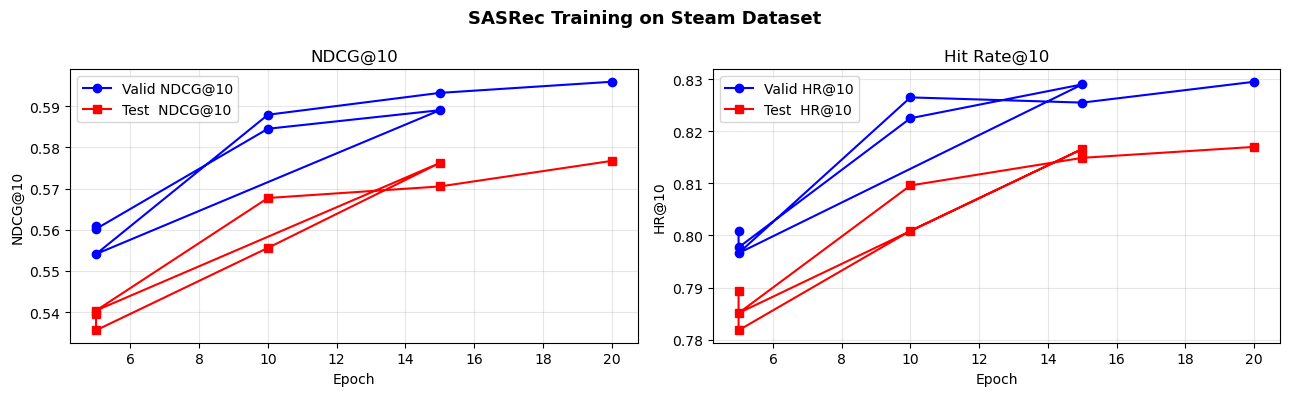

📈 训练曲线已保存至 Steam_default\training_curve.png


In [41]:
import matplotlib.pyplot as plt

epochs_list = []
valid_ndcg, valid_hr = [], []
test_ndcg,  test_hr  = [], []

with open(log_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        # 格式: Epoch 5: Valid_NDCG 0.xxxx, Valid_HR 0.xxxx, Test_NDCG 0.xxxx, Test_HR 0.xxxx
        epochs_list.append(int(parts[1].rstrip(':')))
        valid_ndcg.append(float(parts[3].rstrip(',')))
        valid_hr.append(  float(parts[5].rstrip(',')))
        test_ndcg.append( float(parts[7].rstrip(',')))
        test_hr.append(   float(parts[9]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('SASRec Training on Steam Dataset', fontsize=13, fontweight='bold')

axes[0].plot(epochs_list, valid_ndcg, 'b-o', label='Valid NDCG@10')
axes[0].plot(epochs_list, test_ndcg,  'r-s', label='Test  NDCG@10')
axes[0].set_title('NDCG@10')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('NDCG@10')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_list, valid_hr, 'b-o', label='Valid HR@10')
axes[1].plot(epochs_list, test_hr,  'r-s', label='Test  HR@10')
axes[1].set_title('Hit Rate@10')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('HR@10')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
curve_path = os.path.join(log_dir, 'training_curve.png')
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'📈 训练曲线已保存至 {curve_path}')

In [18]:
import ast

# 用 ast.literal_eval 读取 Python2 格式的文件
game_info = {}
with open(r'D:\Desktop\521group3.25\steam\steam_games.json', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            game = ast.literal_eval(line)
            if 'id' in game and 'title' in game:
                game_info[str(game['id'])] = game
        except:
            continue

print(f'✅ 游戏信息加载完成，共 {len(game_info)} 款游戏')
sample_keys = list(game_info.keys())[:3]
for k in sample_keys:
    print(f'  app_id: {k} → {game_info[k]["title"]}')

✅ 游戏信息加载完成，共 30083 款游戏
  app_id: 761140 → Lost Summoner Kitty
  app_id: 643980 → Ironbound
  app_id: 670290 → Real Pool 3D - Poolians


In [22]:
#加载映射
dataset = data_partition(args.dataset)
[user_train, user_valid, user_test, usernum, itemnum] = dataset

In [23]:
#加载 inv_itemmap
import numpy as np

# 加载 item_id → raw_appid
inv_itemmap = np.load(
    r'D:\Desktop\521group3.25\steam\inv_itemmap.npy',
    allow_pickle=True
).item()

print("映射数量:", len(inv_itemmap))

# 看几个例子
for i,(k,v) in enumerate(inv_itemmap.items()):
    if i>5:
        break
    print("item_id:",k,"→ raw_appid:",v)

映射数量: 11292
item_id: 1 → raw_appid: 328100
item_id: 2 → raw_appid: 35140
item_id: 3 → raw_appid: 35600
item_id: 4 → raw_appid: 631920
item_id: 5 → raw_appid: 506510
item_id: 6 → raw_appid: 1840


In [24]:
#映射
import ast
game_info = {}

with open(r'D:\Desktop\521group3.25\steam\steam_games.json', 'r', encoding='utf-8') as f:
    
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        try:
            game = ast.literal_eval(line)
            
            if 'id' in game and 'title' in game:
                game_info[str(game['id'])] = game['title']
                
        except:
            continue

print("游戏数量:",len(game_info))

# 看几个例子
for i,(k,v) in enumerate(game_info.items()):
    if i>5:
        break
        
    print(k,"→",v)

游戏数量: 30083
761140 → Lost Summoner Kitty
643980 → Ironbound
670290 → Real Pool 3D - Poolians
767400 → 弹炸人2222
772540 → Battle Royale Trainer
774276 → SNOW - All Access Basic Pass


In [25]:
itemname = {}

for iid, rawid in inv_itemmap.items():
    
    name = game_info.get(str(rawid), "Unknown Game")
    
    itemname[iid] = name


print("示例映射:")

for i in range(1,10):
    print(i,"→",itemname.get(i))

示例映射:
1 → Gunspell - Steam Edition
2 → Batman: Arkham Asylum Game of the Year Edition
3 → Big Brain Wolf
4 → Somewhere on Zibylon
5 → Shadows of Adam
6 → Source Filmmaker
7 → Battle of the Bulge
8 → Goliath
9 → Sudokuball Detective


In [47]:
def recommend_user(user_id, topk=10):

    seq = np.zeros([args.maxlen], dtype=np.int32)

    idx = args.maxlen - 1

    # 构建用户历史序列
    for i in reversed(user_train[user_id]):
        
        seq[idx] = i
        idx -= 1
        
        if idx == -1:
            break

    rated = set(user_train[user_id])

    item_idx = []

    for i in range(1, itemnum+1):
        if i not in rated:
            item_idx.append(i)

    predictions = -model.predict(sess,[user_id],[seq],item_idx)[0]

    ranked = np.argsort(predictions)

    rec_items = [item_idx[i] for i in ranked[:topk]]

    return rec_items

In [49]:
user_id = 1

rec_items = recommend_user(user_id)

print("推荐游戏：\n")

for i,item in enumerate(rec_items):

    name = itemname.get(item,"Unknown")

    print(f"{i+1}. {name}")

推荐游戏：

1. Deep Space Dash
2. Trashville
3. Hiiro
4. Turn Around
5. Cavern Escape
6. Midnight Carnival
7. - Arcane preRaise -
8. PLANETS OF WAR
9. Zup! 3
10. The Thirst of Hearts


In [53]:
def recommend_user(user_id, topk=10):

    seq = np.zeros([args.maxlen], dtype=np.int32)

    idx = args.maxlen - 1

    # 构建用户历史序列
    for i in reversed(user_train[user_id]):

        seq[idx] = i
        idx -= 1

        if idx == -1:
            break

    rated = set(user_train[user_id])

    item_idx = []

    for i in range(1, itemnum + 1):
        if i not in rated:
            item_idx.append(i)

    # 模型预测
    predictions = -model.predict(sess, [user_id], [seq], item_idx)[0]

    # 排序
    ranked = np.argsort(predictions)

    # 取TopK
    top_indices = ranked[:topk]

    top_items = [item_idx[i] for i in top_indices]

    top_scores = predictions[top_indices]

    # ===== 只对TopK做softmax =====
    exp_scores = np.exp(top_scores - np.max(top_scores))
    probs = exp_scores / exp_scores.sum()

    results = []

    for item, score, prob in zip(top_items, top_scores, probs):

        results.append((item, score, prob))

    return results

In [68]:
#新
def recommend_user(user_id, topk=10):

    seq = np.zeros([args.maxlen], dtype=np.int32)
    idx = args.maxlen - 1

    # 用户历史
    for i in reversed(user_train[user_id]):
        seq[idx] = i
        idx -= 1
        if idx == -1:
            break

    rated = set(user_train[user_id])

    item_idx = []
    for i in range(1, itemnum+1):
        if i not in rated:
            item_idx.append(i)

    # 预测score
    predictions = model.predict(sess,[user_id],[seq],item_idx)[0]

    # 排序（score高 → 前）
    ranked_idx = np.argsort(predictions)[::-1]

    top_items = [item_idx[i] for i in ranked_idx[:topk]]
    top_scores = [predictions[i] for i in ranked_idx[:topk]]

    # 计算softmax置信度
    scores = np.array(top_scores)
    exp_scores = np.exp(scores - np.max(scores))
    probs = exp_scores / np.sum(exp_scores)

    # 组合结果
    results = []
    for item,score,conf in zip(top_items,top_scores,probs):
        results.append((item,score,conf))

    return results

In [69]:
import json

game_tags = {}
game_appid = {}

with open(r'D:\Desktop\521group3.25\steam\steam_games.json', 'r', encoding='utf-8') as f:
    
    for line in f:
        
        try:
            data = eval(line)
            
            name = data.get("app_name")
            appid = data.get("id")
            
            tags = data.get("tags") or data.get("genres") or []
            
            if name:
                
                # 根据游戏名称匹配 item_id
                for k,v in itemname.items():
                    
                    if v == name:
                        
                        game_tags[k] = tags[:3]   # 取前3个核心标签
                        game_appid[k] = appid
                        
        except:
            continue

print("游戏标签映射完成")
print("共加载游戏：",len(game_tags))

游戏标签映射完成
共加载游戏： 11174


In [70]:
def show_user_profile(user_id, n=5):

    print(f"\n🧑 用户 {user_id} 最近玩过的游戏\n")

    history = user_train[user_id][-n:]

    for i,item in enumerate(reversed(history)):

        name = itemname.get(item,"Unknown")

        tags = game_tags.get(item,["Unknown"])

        print(f"{i+1}. {name}")
        print(f"   item_id = {item}")
        print(f"   核心标签 = {', '.join(tags)}\n")

In [71]:
def show_recommendations(user_id, topk=10):

    results = recommend_user(user_id, topk)

    print(f"\n🎮 推荐游戏 Top{topk}\n")

    for rank,(item,score,conf) in enumerate(results,1):

        name = itemname.get(item,"Unknown")

        appid = game_appid.get(item,"Unknown")

        tags = game_tags.get(item,["Unknown"])

        print(f"{rank}. {name}")
        print(f"   item_id = {item}")
        print(f"   appid = {appid}")
        print(f"   推荐置信度 = {conf*100:.2f}%")
        print(f"   核心标签 = {', '.join(tags)}\n")

In [72]:
user_id = 1

show_user_profile(user_id)

show_recommendations(user_id)


🧑 用户 1 最近玩过的游戏

1. The Land Of Lamia
   item_id = 8302
   核心标签 = Adventure, Indie, Puzzle

2. The Lady
   item_id = 3689
   核心标签 = Indie, Action, Adventure

3. POSTAL
   item_id = 2464
   核心标签 = Action, Classic, Dark Humor

4. Oh No! Bugs!
   item_id = 1364
   核心标签 = Indie, Casual, Co-op

5. Sam &amp; Max 202: Moai Better Blues
   item_id = 11178
   核心标签 = Unknown


🎮 推荐游戏 Top10

1. Deep Space Dash
   item_id = 6847
   appid = 493650
   推荐置信度 = 23.00%
   核心标签 = Action, Indie, Casual

2. Trashville
   item_id = 9697
   appid = 589390
   推荐置信度 = 12.59%
   核心标签 = Action, Indie

3. Hiiro
   item_id = 9234
   appid = 464960
   推荐置信度 = 11.54%
   核心标签 = Adventure, Casual, Indie

4. Turn Around
   item_id = 1574
   appid = 595340
   推荐置信度 = 10.17%
   核心标签 = Indie, Action, Adventure

5. Cavern Escape
   item_id = 2645
   appid = 546400
   推荐置信度 = 8.17%
   核心标签 = Adventure, Casual, Indie

6. Midnight Carnival
   item_id = 11242
   appid = 546980
   推荐置信度 = 8.04%
   核心标签 = Early Access, Casual, 